## Importing necessary Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import pandas as pd
from torch.cuda.amp import autocast

# Check if CUDA (GPU) is available and set the device accordingly
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Defining Dataset Class and Visualizing Audio Data

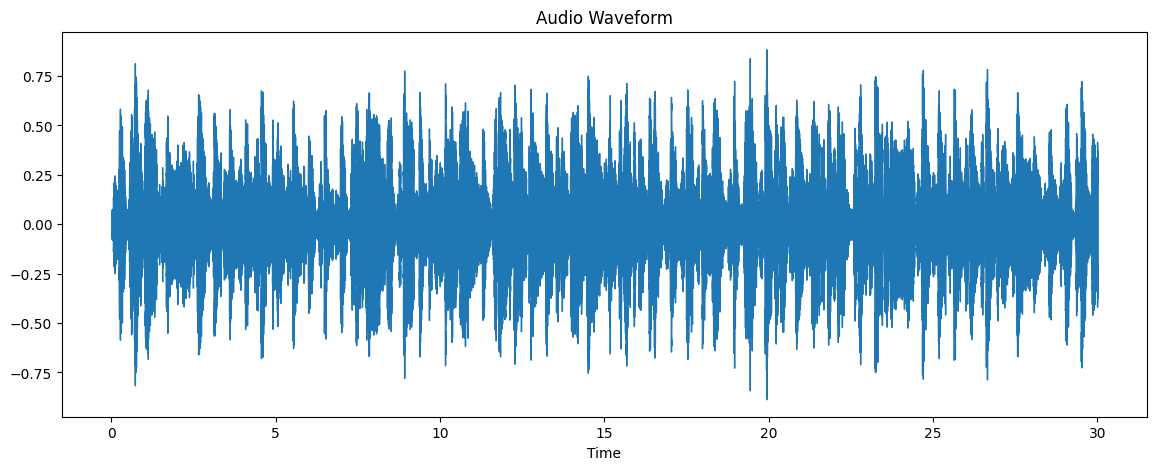

In [ ]:
class AudioDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        y = self.labels[idx]
        # Return CPU tensors; move them to device in the training loop
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

# Function to visualize audio data
def visualize_audio(file_path):
    # Load the audio file
    audio_data, sample_rate = librosa.load(file_path, sr=None)

    # Plot the waveform
    plt.figure(figsize=(14, 5))
    librosa.display.waveshow(audio_data, sr=sample_rate)
    plt.title("Audio Waveform")
    plt.show()

    return audio_data, sample_rate

# Example file path
file_path = "./blues.00000.wav"
audio_data, sample_rate = visualize_audio(file_path)


## Splitting Audio into Chunks and Visualizing

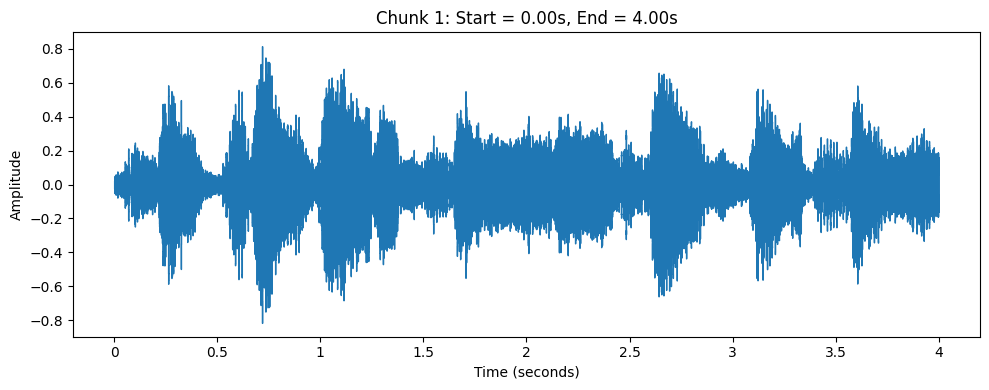

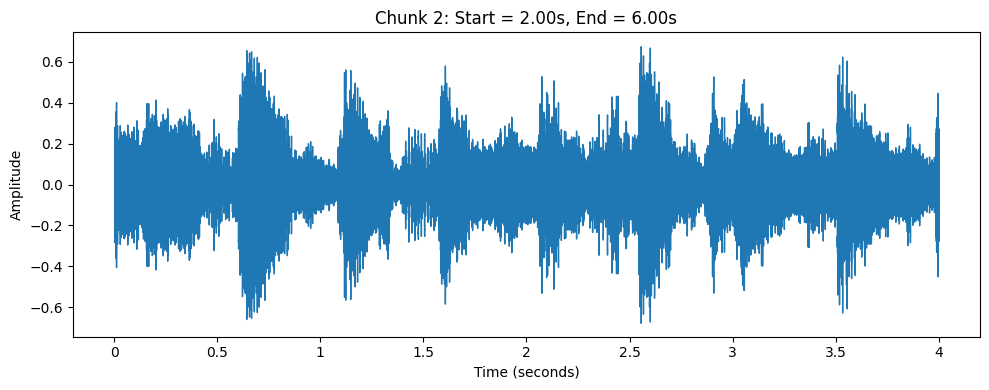

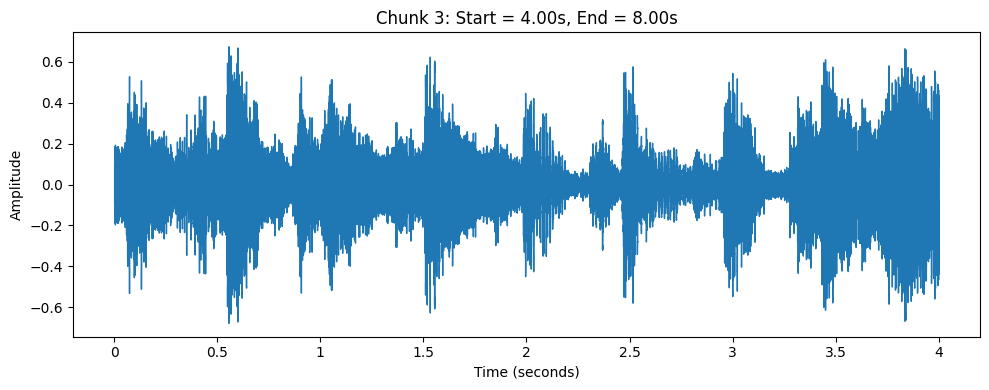

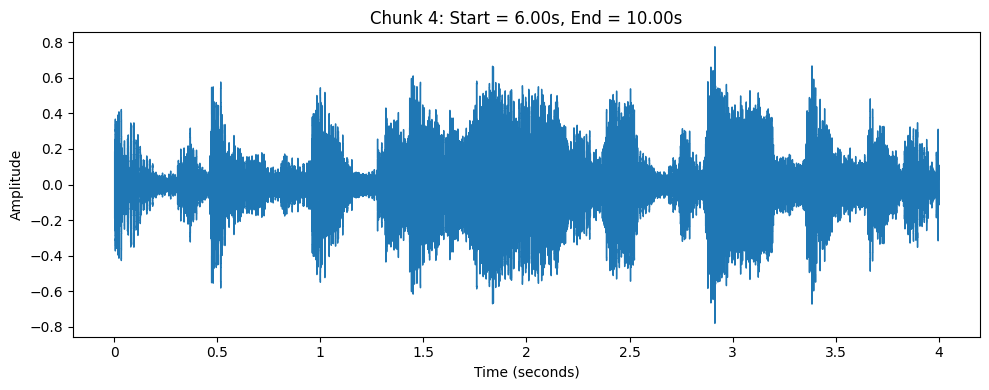

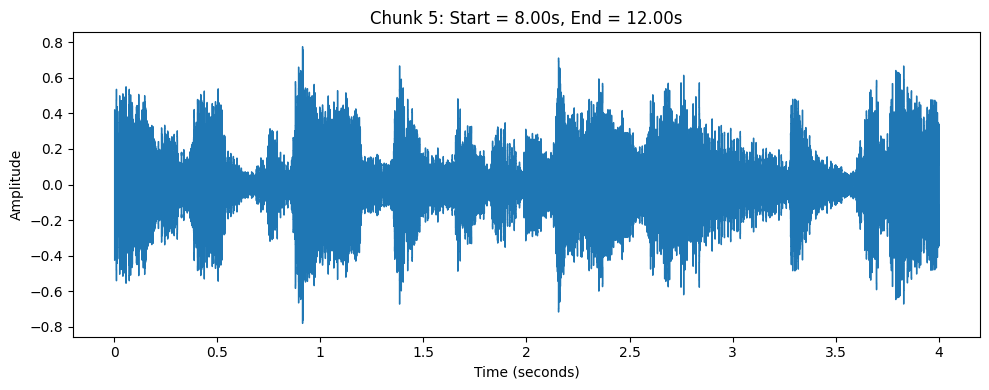

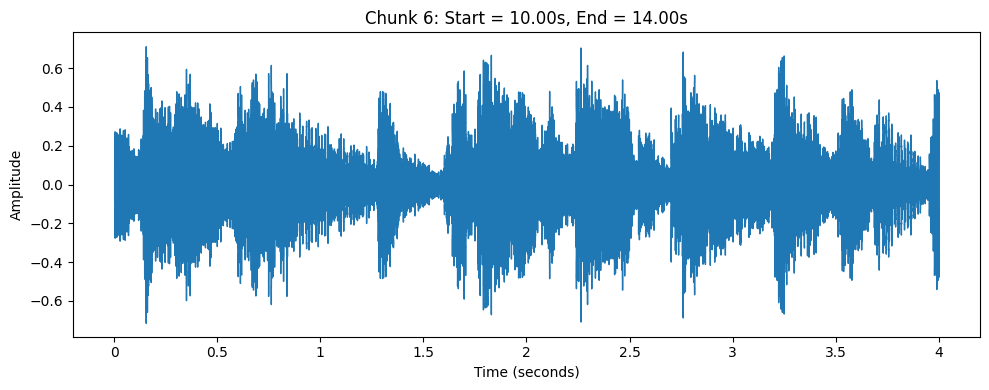

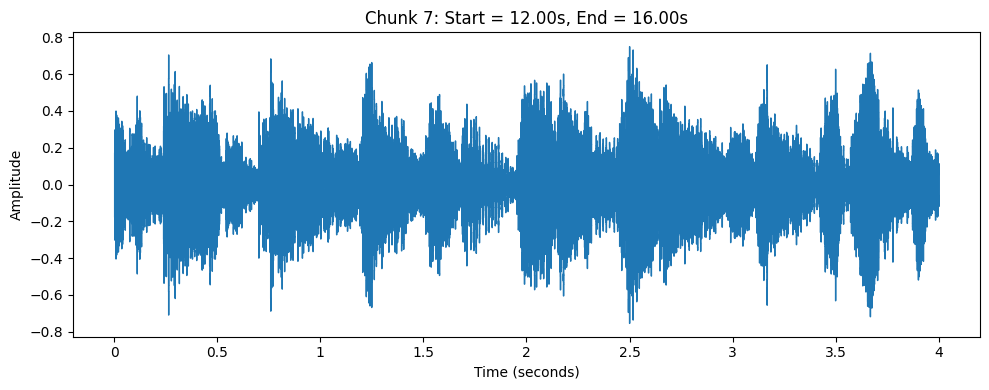

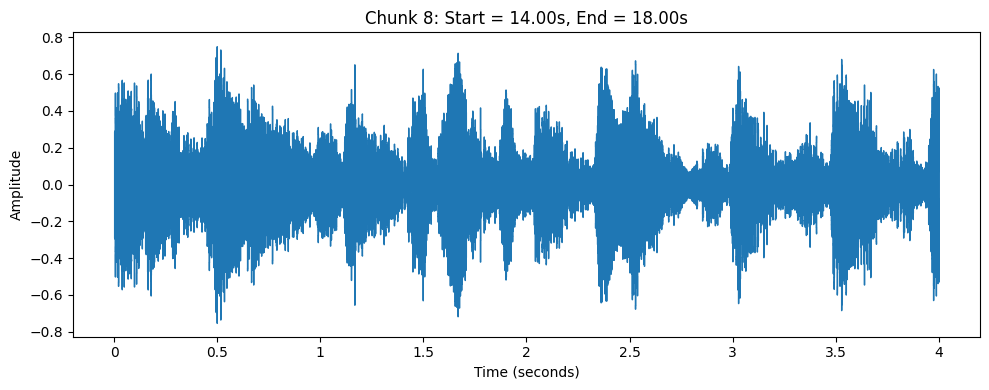

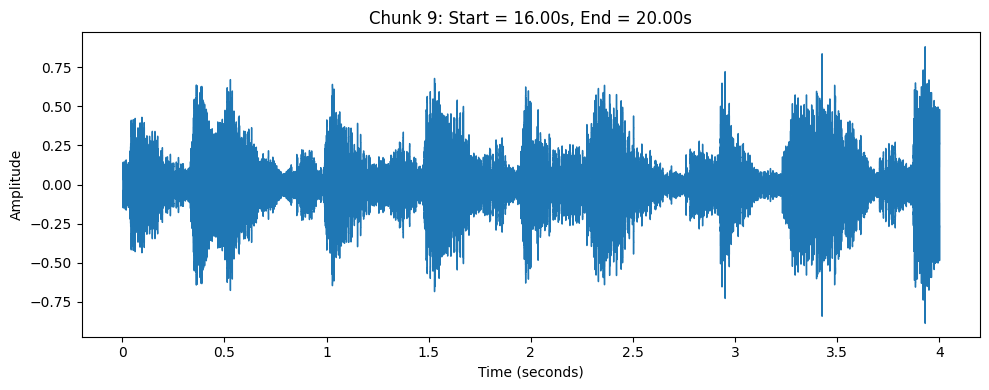

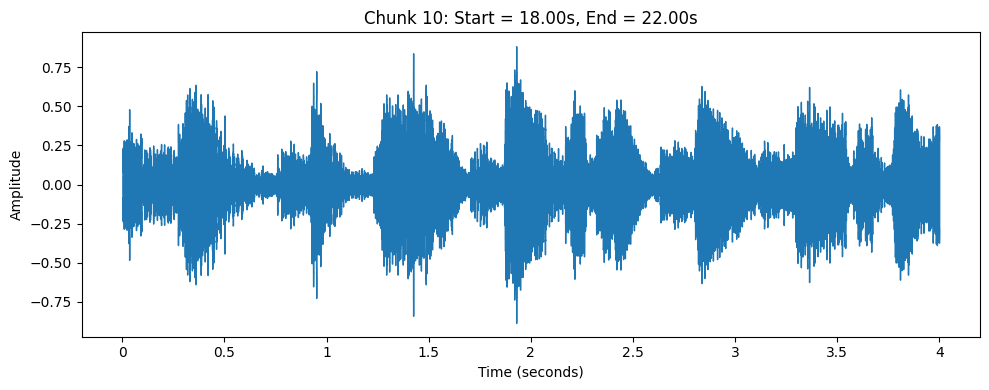

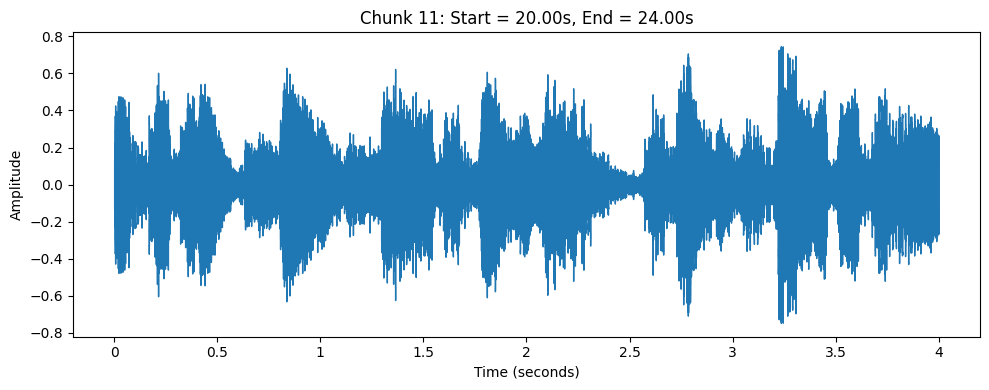

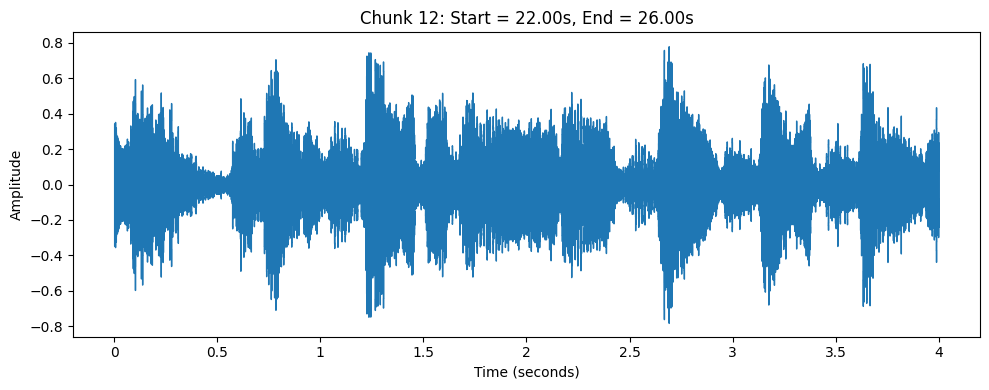

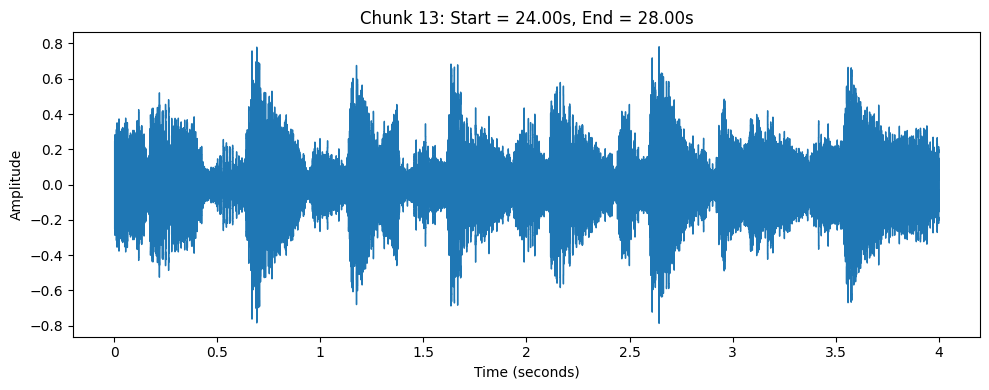

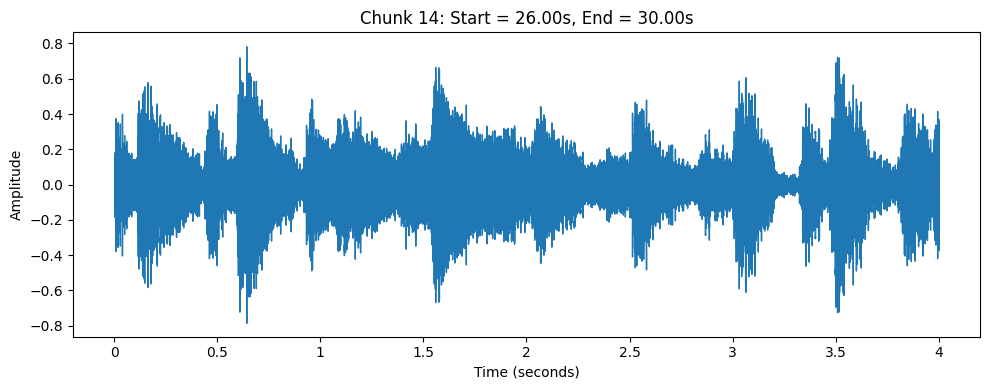

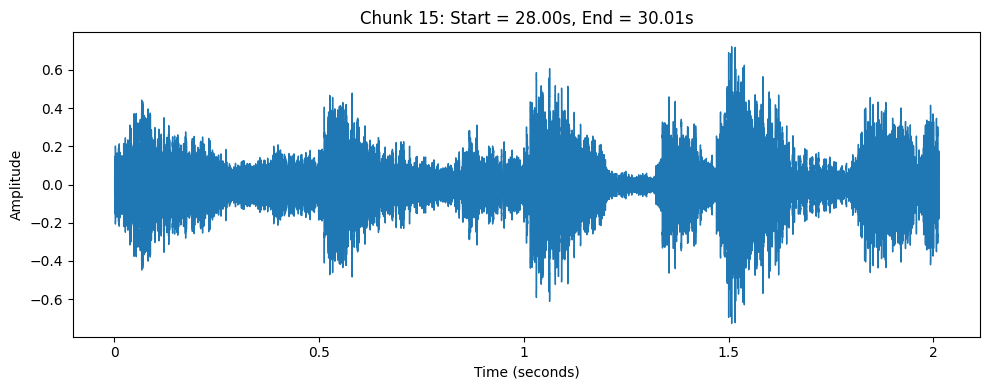

In [ ]:
def split_audio_to_chunks(file_path, chunk_duration=4, overlap_duration=2):
    # Load the audio file
    audio_data, sample_rate = librosa.load(file_path, sr=None)

    # Calculate the number of samples per chunk and overlap
    chunk_samples = chunk_duration * sample_rate
    overlap_samples = overlap_duration * sample_rate

    # Calculate the number of chunks
    num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

    # Split audio into chunks
    chunks = []
    for i in range(num_chunks):
        start = i * (chunk_samples - overlap_samples)
        end = min(start + chunk_samples, len(audio_data))
        chunk = audio_data[start:end]
        chunks.append(chunk)

        # Visualizing the chunks
        plt.figure(figsize=(10, 4))
        librosa.display.waveshow(chunk, sr=sample_rate)
        start_time = start / sample_rate
        end_time = end / sample_rate
        plt.title(f"Chunk {i+1}: Start = {start_time:.2f}s, End = {end_time:.2f}s")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()

    return chunks, sample_rate

chunks, sample_rate = split_audio_to_chunks(file_path, chunk_duration=4, overlap_duration=2)


## Mel-Spectrogram and Preprocessing the Data

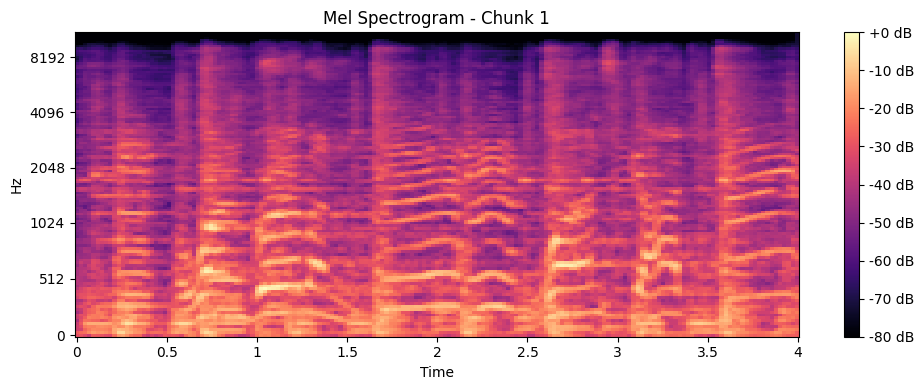

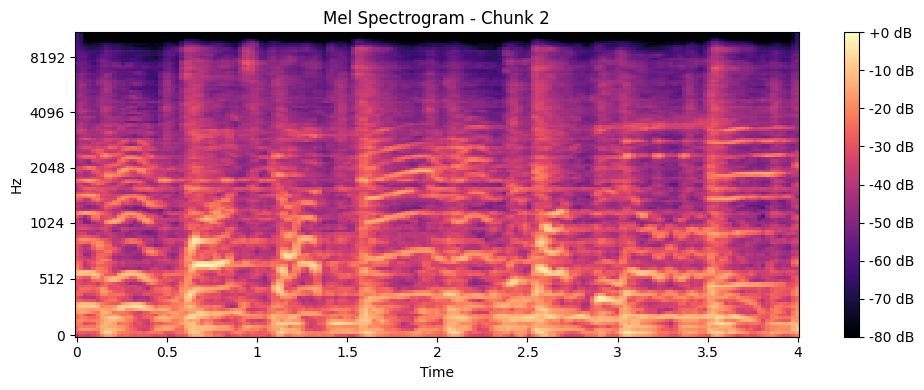

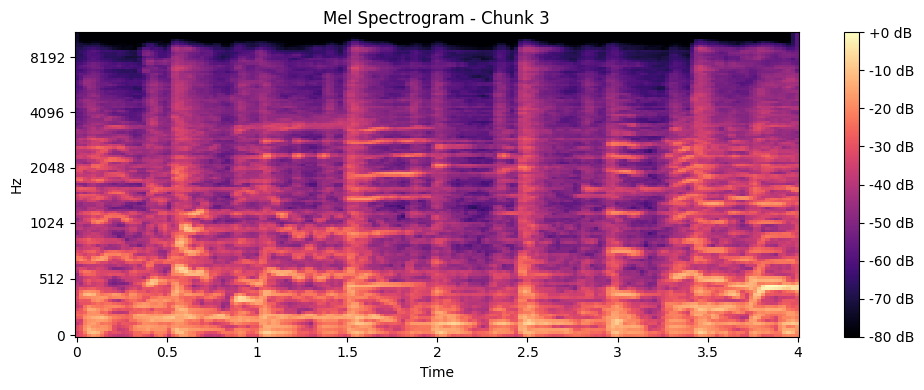

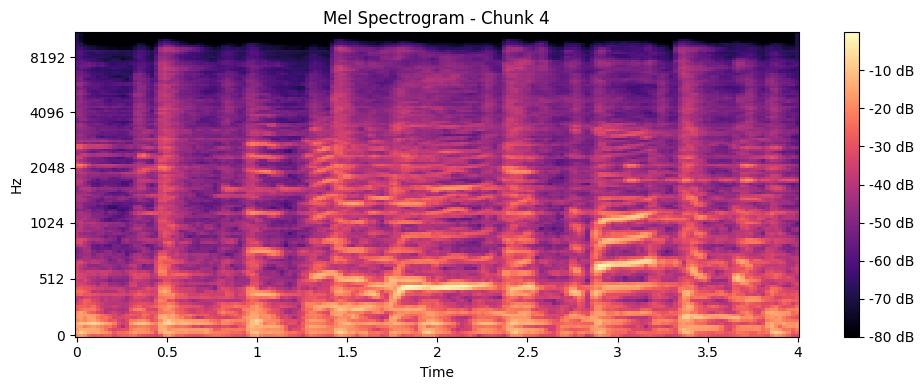

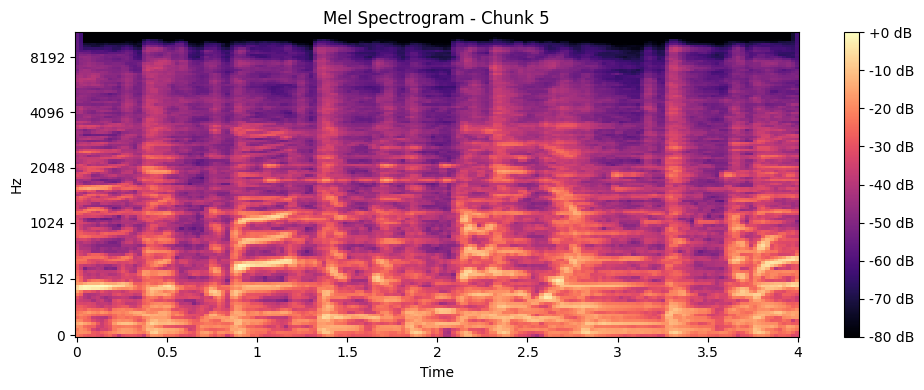

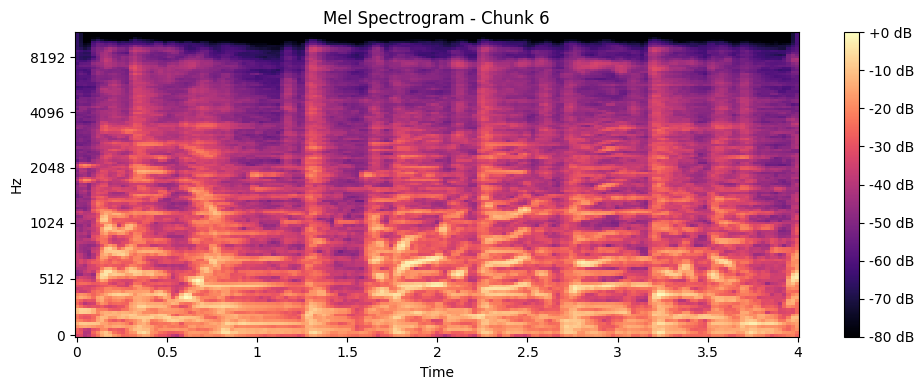

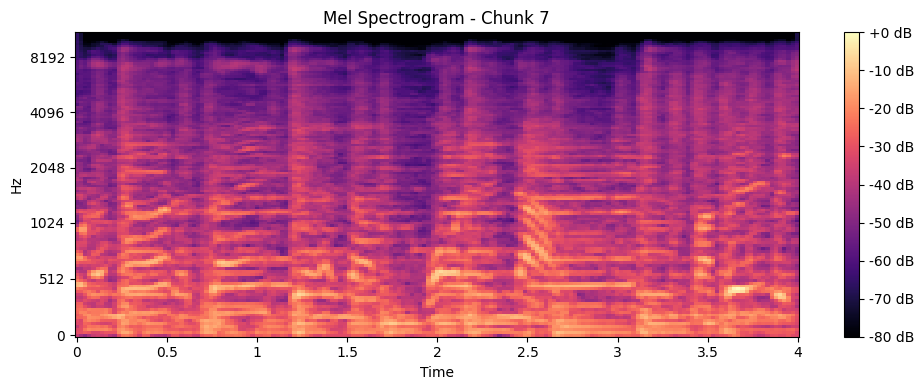

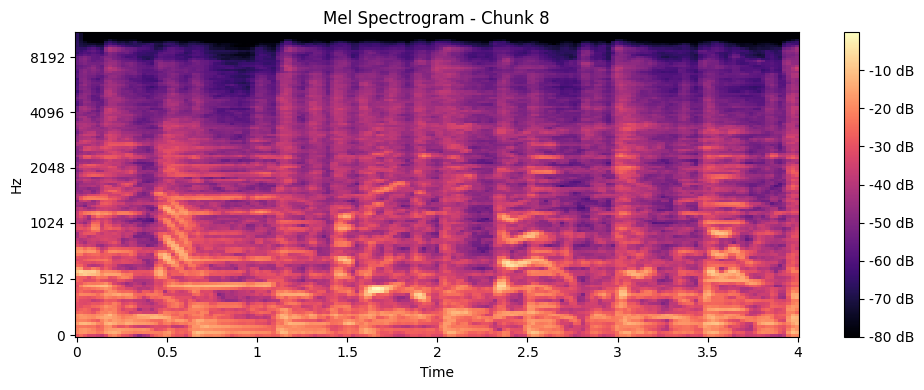

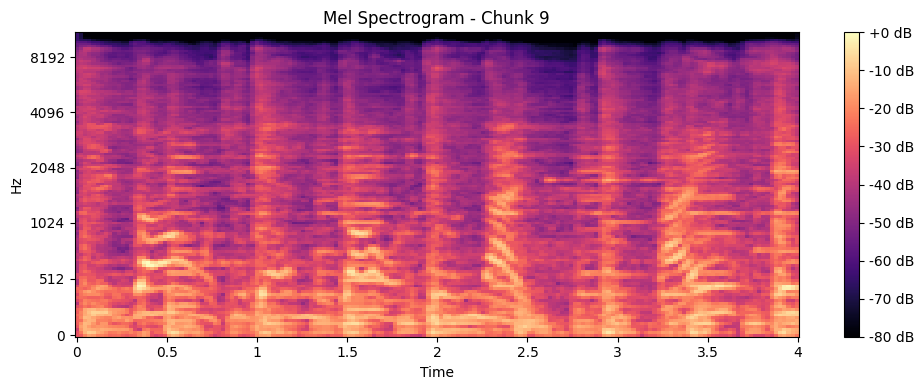

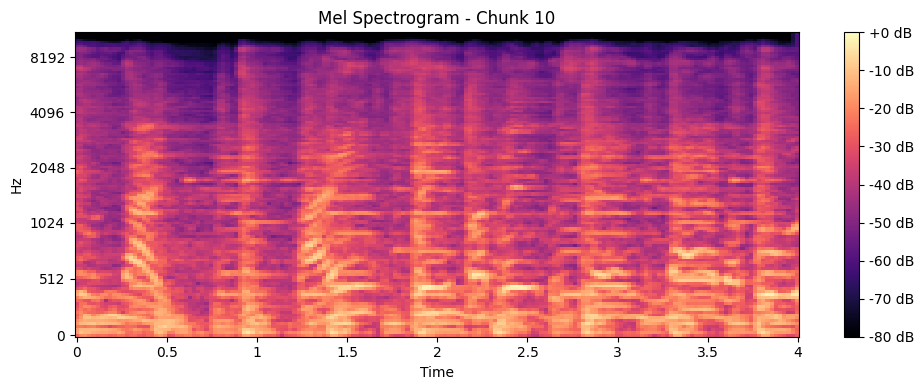

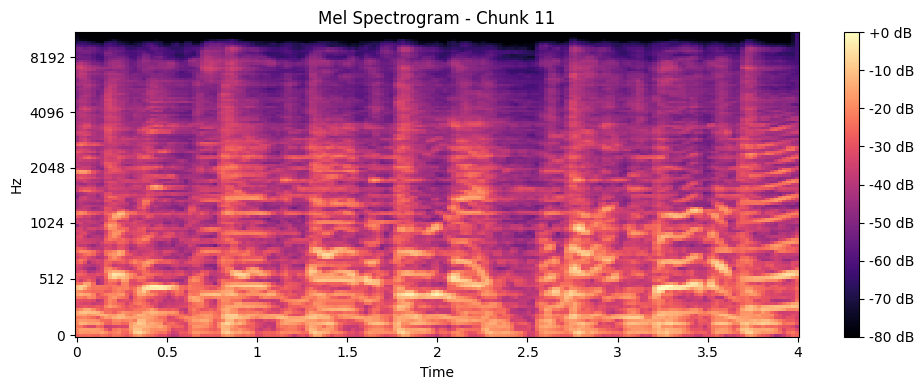

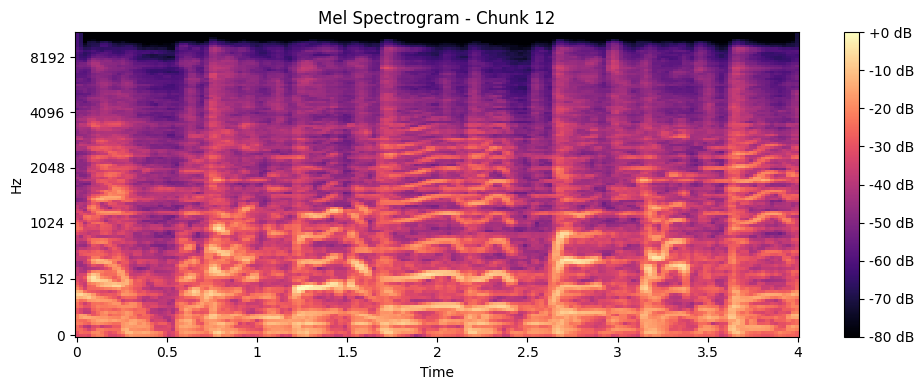

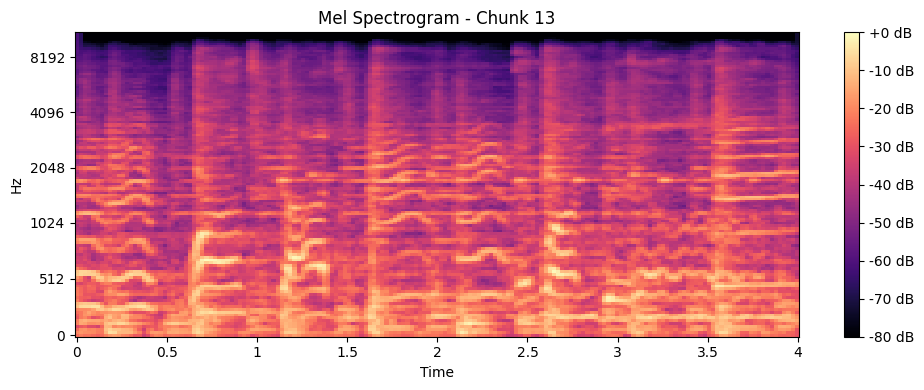

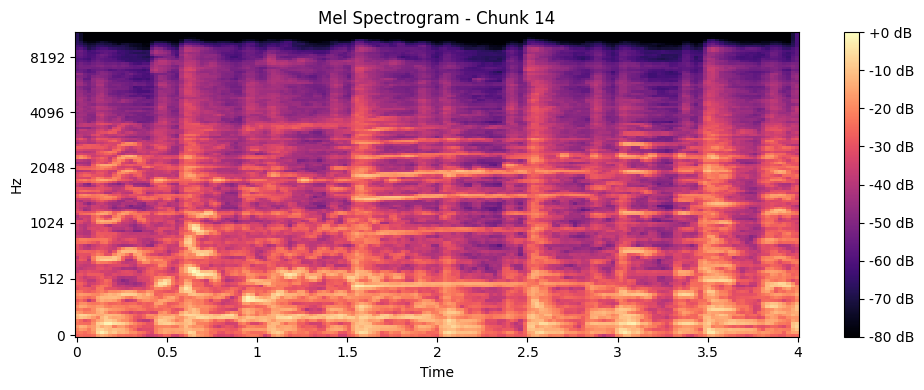

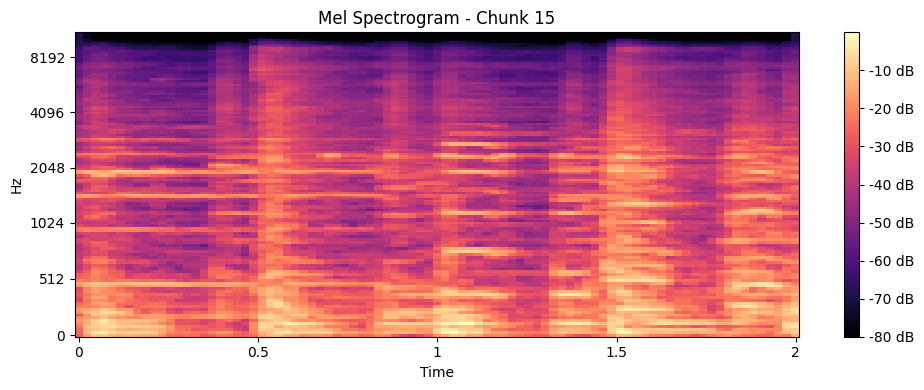

In [ ]:
def visualize_melspectrogram(audio_data, sample_rate, chunk_duration=4, overlap_duration=2, target_shape=(128, 128)):
    # Calculate the number of samples for each chunk and overlap
    chunk_samples = chunk_duration * sample_rate
    overlap_samples = overlap_duration * sample_rate

    # Number of chunks
    num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

    # Visualize each chunk's mel spectrogram
    for i in range(num_chunks):
        start = i * (chunk_samples - overlap_samples)
        end = start + chunk_samples

        chunk = audio_data[start:end]

        # Generate mel spectrogram for each chunk
        mel_spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sample_rate, n_mels=target_shape[0])
        mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

        # Plot the mel spectrogram
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(mel_spectrogram_db, sr=sample_rate, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f'Mel Spectrogram - Chunk {i + 1}')
        plt.tight_layout()
        plt.show()

visualize_melspectrogram(audio_data, sample_rate, chunk_duration=4, overlap_duration=2, target_shape=(128, 128))

 ## Loading and Preprocessing Audio Files

In [ ]:
def load_and_preprocess_data(data_dir, classes, target_shape=(128, 128)):
    data = []
    labels = []
    for i_class, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        print(f"Processing-- {class_name}")
        for filename in os.listdir(class_dir):
            if filename.endswith('.wav'):
                file_path = os.path.join(class_dir, filename)
                audio_data, sample_rate = librosa.load(file_path, sr=None)
                chunk_duration = 4  # seconds
                overlap_duration = 2  # seconds
                chunk_samples = chunk_duration * sample_rate
                overlap_samples = overlap_duration * sample_rate
                num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

                for i in range(num_chunks):
                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples
                    chunk = audio_data[start:end]

                    mel_spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sample_rate, n_mels=target_shape[0])
                    mel_spectrogram = librosa.util.fix_length(mel_spectrogram, size=target_shape[1])
                    mel_spectrogram = np.expand_dims(mel_spectrogram, axis=0)  # add channel dimension
                    data.append(mel_spectrogram)
                    labels.append(i_class)

    return np.array(data), np.array(labels)


# Example data directory path and classes
data_dir = "./genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop',
           'jazz', 'metal', 'pop', 'reggae', 'rock']

# Load data
data, labels = load_and_preprocess_data(data_dir, classes)

# Split the data into training and validation
X_train, X_val, Y_train, Y_val = train_test_split(
    data, labels, val_size=0.2, random_state=42
)

Processing-- blues
Processing-- classical
Processing-- country
Processing-- disco
Processing-- hiphop
Processing-- jazz
Processing-- metal
Processing-- pop
Processing-- reggae
Processing-- rock


## Creating DataLoaders and Defining the CNN Model

In [ ]:
# Create datasets
train_dataset = AudioDataset(X_train, Y_train)
val_dataset = AudioDataset(X_val, Y_val)

# Creating DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16,shuffle=False)

class MusicGenreClassifier(nn.Module):
    def __init__(self):
        super(MusicGenreClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding='same')
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        # Calculate the input size for the fully connected layer
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 128, 128)
            x = F.relu(self.conv1(dummy_input))
            x = F.relu(self.conv2(x))
            x = self.pool(F.relu(self.conv3(x)))
            self.fc1_input_size = x.view(1, -1).shape[1]

        self.fc1 = nn.Linear(self.fc1_input_size, 1200)
        self.fc2 = nn.Linear(1200, 10)  # 10 output classes

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)


## Evaluating the Model on Validation Data (After Training)

In [ ]:
# Evaluation function to calculate validation loss and accuracy
def evaluate_model(model, loader, criterion):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():  # No need to compute gradients for evaluation
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    average_loss = running_loss / len(test_loader)
    print(f"Val Loss: {average_loss:.4f}, Val Accuracy: {accuracy:.2f}%")
    return average_loss, accuracy

## Training


In [ ]:
# Instantiate the model
model = MusicGenreClassifier().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


# Initialize lists to store training and validation metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15):
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()  # Zero the gradients

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):  # Enable mixed precision
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss.backward()  # Backpropagation

            optimizer.step()  # Update the model's weights

            # Update loss and accuracy
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Calculate training loss and accuracy for the epoch
        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Validate the model
        val_loss, val_accuracy = evaluate_model(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15)

Epoch [1/15], Train Loss: 2.2171, Train Accuracy: 47.81%, Val Loss: 1.1201, Val Accuracy: 62.13%
Epoch [2/15], Train Loss: 0.7066, Train Accuracy: 77.60%, Val Loss: 1.1085, Val Accuracy: 65.47%
Epoch [3/15], Train Loss: 0.3555, Train Accuracy: 89.51%, Val Loss: 1.0427, Val Accuracy: 69.91%
Epoch [4/15], Train Loss: 0.2233, Train Accuracy: 94.08%, Val Loss: 1.3381, Val Accuracy: 66.51%
Epoch [5/15], Train Loss: 0.1488, Train Accuracy: 96.34%, Val Loss: 1.2583, Val Accuracy: 68.80%
Epoch [6/15], Train Loss: 0.1016, Train Accuracy: 97.59%, Val Loss: 1.4363, Val Accuracy: 67.76%
Epoch [7/15], Train Loss: 0.0916, Train Accuracy: 98.07%, Val Loss: 1.3932, Val Accuracy: 68.21%
Epoch [8/15], Train Loss: 0.0963, Train Accuracy: 97.95%, Val Loss: 1.4456, Val Accuracy: 67.56%
Epoch [9/15], Train Loss: 0.0646, Train Accuracy: 98.56%, Val Loss: 1.5170, Val Accuracy: 69.26%
Epoch [10/15], Train Loss: 0.0454, Train Accuracy: 99.00%, Val Loss: 1.5795, Val Accuracy: 67.89%
Epoch [11/15], Train Loss: 0.

## Plot of Training and Validation Curves

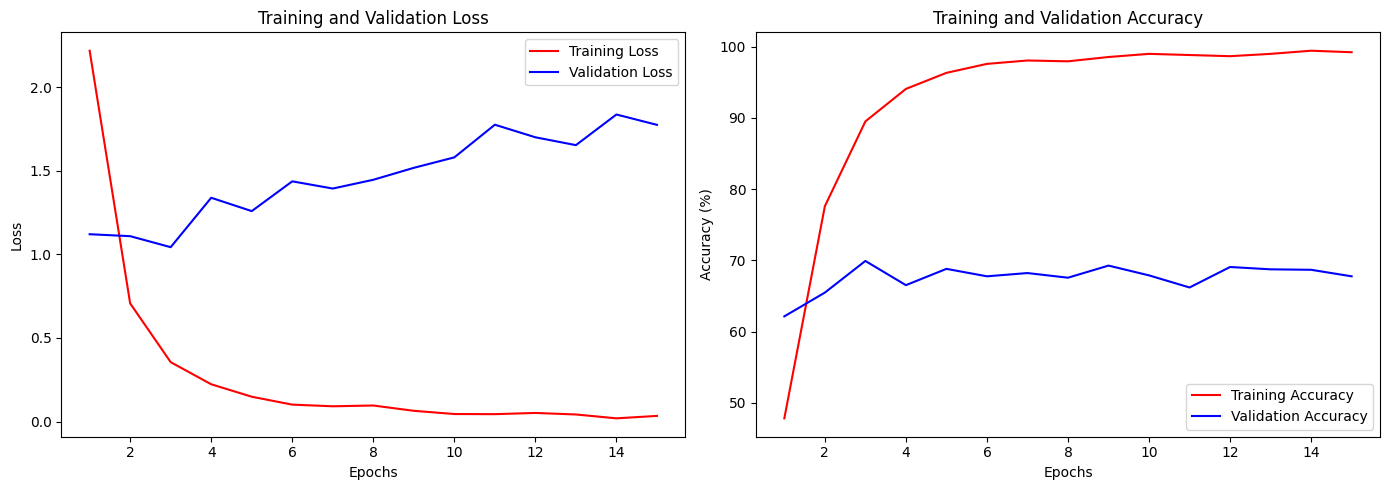

In [ ]:
# Plot the training and validation curves
def plot_training_curves(train_losses, train_accuracies, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    # Plot Loss
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'r', label='Training Loss')
    plt.plot(epochs, val_losses, 'b', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'r', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'b', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()
# Plot the training curves after the training process
plot_training_curves(train_losses, train_accuracies, val_losses, val_accuracies)

## Confusion Matrix

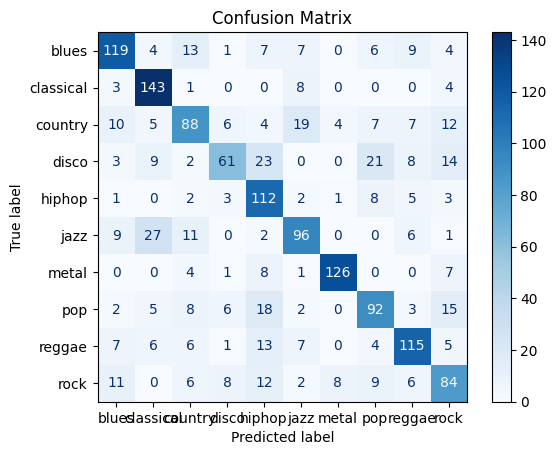

<Figure size 2000x2000 with 0 Axes>

In [ ]:
# Confusion Matrix Function
def plot_confusion_matrix(model, loader, classes):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.figure(figsize=(20, 20))
    plt.show()
# Plot confusion matrix after training
classes = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
plot_confusion_matrix(model, test_loader, classes)

## Saving and Loading the Model

In [ ]:
torch.save(model.state_dict(), "music_genre_classifier.pth")